
Kebutuhan Kalori Harian: 3061.11 kcal


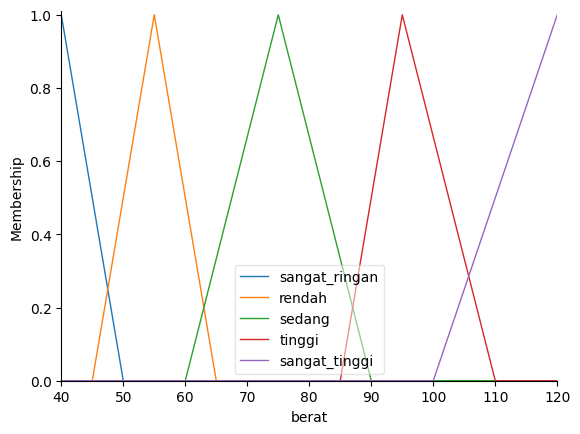

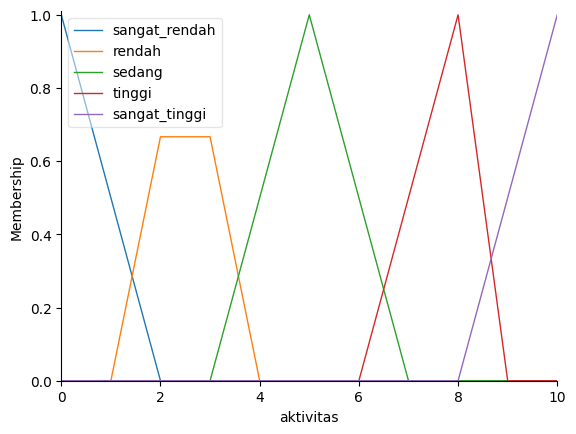

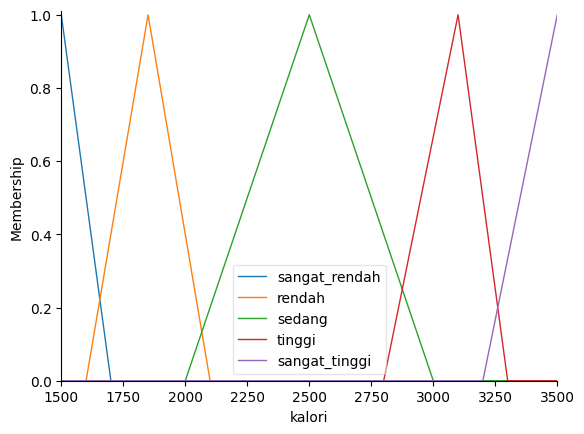

In [5]:
# Fuzzy Mamdani 5x5 Template (Jupyter Notebook)

import numpy as np
import skfuzzy as fuzz
from skfuzzy import control as ctrl
import matplotlib.pyplot as plt

# ===================== INPUT =====================
berat = ctrl.Antecedent(np.arange(40,121,1), 'berat')
aktivitas = ctrl.Antecedent(np.arange(0,11,1), 'aktivitas')

# ===================== OUTPUT =====================
kalori = ctrl.Consequent(np.arange(1500,3501,1), 'kalori')

# ===================== MEMBERSHIP BERAT (5 level) =====================
berat['sangat_ringan'] = fuzz.trimf(berat.universe, [40, 40, 50])
berat['rendah'] = fuzz.trimf(berat.universe, [45, 55, 65])
berat['sedang'] = fuzz.trimf(berat.universe, [60, 75, 90])
berat['tinggi'] = fuzz.trimf(berat.universe, [85, 95, 110])
berat['sangat_tinggi'] = fuzz.trimf(berat.universe, [100, 120, 120])

# ===================== MEMBERSHIP AKTIVITAS (5 level) =====================
aktivitas['sangat_rendah'] = fuzz.trimf(aktivitas.universe, [0,0,2])
aktivitas['rendah'] = fuzz.trimf(aktivitas.universe, [1,2.5,4])
aktivitas['sedang'] = fuzz.trimf(aktivitas.universe, [3,5,7])
aktivitas['tinggi'] = fuzz.trimf(aktivitas.universe, [6,8,9])
aktivitas['sangat_tinggi'] = fuzz.trimf(aktivitas.universe, [8,10,10])

# ===================== MEMBERSHIP KALORI (5 level) =====================
kalori['sangat_rendah'] = fuzz.trimf(kalori.universe, [1500, 1500, 1700])
kalori['rendah'] = fuzz.trimf(kalori.universe, [1600, 1850, 2100])
kalori['sedang'] = fuzz.trimf(kalori.universe, [2000, 2500, 3000])
kalori['tinggi'] = fuzz.trimf(kalori.universe, [2800, 3100, 3300])
kalori['sangat_tinggi'] = fuzz.trimf(kalori.universe, [3200, 3500, 3500])

# ===================== RULE 5x5 =====================
rules = []
berat_levels = ['sangat_ringan','rendah','sedang','tinggi','sangat_tinggi']
aktivitas_levels = ['sangat_rendah','rendah','sedang','tinggi','sangat_tinggi']
kalori_levels = ['sangat_rendah','rendah','sedang','tinggi','sangat_tinggi']

# Loop membuat 25 rule
for i, b in enumerate(berat_levels):
    for j, a in enumerate(aktivitas_levels):
        # Assign output kalori berdasarkan posisi (contoh sederhana: rata-rata posisi)
        out_index = min(i+j, 4)  # index max = 4
        rules.append(ctrl.Rule(berat[b] & aktivitas[a], kalori[kalori_levels[out_index]]))

# ===================== SISTEM =====================
system = ctrl.ControlSystem(rules)
sim = ctrl.ControlSystemSimulation(system)

# ===================== INPUT =====================
berat_input = float(input("Masukkan berat badan (kg): "))
aktivitas_input = float(input("Masukkan tingkat aktivitas (0-10): "))

sim.input['berat'] = berat_input
sim.input['aktivitas'] = aktivitas_input

# ===================== HITUNG =====================
sim.compute()

print("\nKebutuhan Kalori Harian: {:.2f} kcal".format(sim.output['kalori']))

# ===================== GRAFIK =====================
berat.view()
aktivitas.view()
kalori.view()
plt.show()
